### Good reading blog, machinelearning.apple.com/research/

# Pytorch Computer Vision

* See reference Notebook -
* See reference online book -

## 0. Computer vision libraries in PyTorch

* `torchvision` - [base domain library for torchvision]
* `torchvision.datasets` - get datasets and data loading functions for computer vision
* `torchvision.models` - get pretained computerviison models that you can leverage for your own problems
* `torchvision.transforms` - functions for manipulating your vison data (images) to be suitable for use with an ML model
* `torch.utils.data.Dataset` - Base dataset class for PyTorch.
* `torch.utils.data.DataLoader` - Creates a Python iterable over a dataset

### Reminder: ***Read the PyTorch documentation of Computer Vision***

***LINK: pytorch.org/vision/stable/transforms.html***

In [1]:
# import PyTorch

import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Check versions
print(torch.__version__)
print(torchvision.__version__)

2.13.0+cu126
0.28.0+cu126


## 1. Getting a Dataset

The data we'll be using is Fashion MNIST
ol 

In [2]:
from torchvision import datasets

train_data = datasets.FashionMNIST(
    root = "datasets", # where to download the data?
    train= True, # do we want the training dataset?
    download = True, # Do we want to download?
    transform = torchvision.transforms.ToTensor(), # How do we want to transofmr the data
    target_transform = None # How do we want to transform the lables/targets
    )

test_data = datasets.FashionMNIST(
    root = "datasets",
    train=False,
    download = True,
    transform = torchvision.transforms.ToTensor(),
    target_transform = None
)

In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# train_data[0]

In [5]:
# See the first training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [6]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
# Gives a list of classes

train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [8]:
# Gives the labels as well as the indices

class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [9]:
image.shape

torch.Size([1, 28, 28])

In [10]:
# Check the shape of our image

print(f"Image Shape: {image.shape} -> [color_channels, height, width]")
print(f"Image label: {class_names[label]}")

Image Shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image label: Ankle boot


Image shape: torch.Size([1, 28, 28])


tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

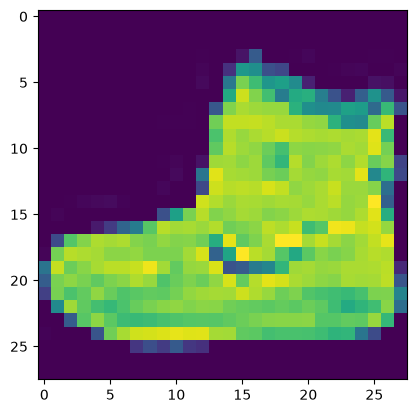

In [11]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
image

Text(0.5, 1.0, 'Ankle boot')

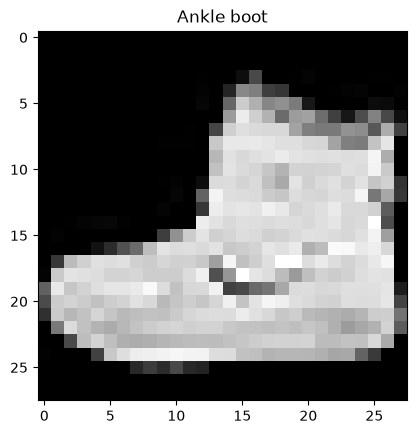

In [12]:
plt.imshow(image.squeeze(), cmap = "gray");
plt.title(class_names[label])

In [13]:
# random_idx = torch.randint(0, len(train_data), size = [1]).item()
# random_idx

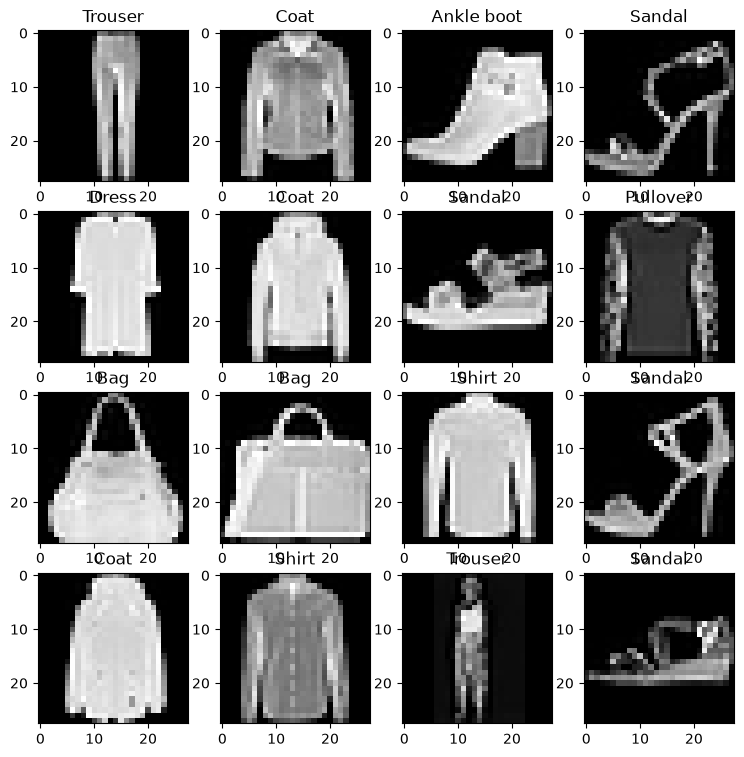

In [14]:
# Plot more images
# torch.manual_seed(42)
fig = plt.figure(figsize = (9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(train_data), size = [1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap = "gray")
    plt.title(class_names[label])

Do you think these items of clothing (images) could be modelled with pure linear lines or do you think we'll need non-linearities?

In [15]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: datasets
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: datasets
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Prepare DataLoader

Right now our data is in the form of PyTorch Datasets.

DataLoader turns out dataset into a Python iterable

More specificallly, we want to turn our data into batches (ior mini-batches)

Why would we do this?

1. It is more computationally efficient, as in your computing hardware may noty be able to loook (store in memeory) at 60000 images in one hit. So we break it down to 32 images at a time (batch size of 32)
2. It gives our neural network more chances to update it's gradients per epoch

In [16]:
# Mini batches follows you everywhere regardless of data (photo, video, audio, etc)

from torch.utils.data import DataLoader

# setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_data,
                             batch_size = BATCH_SIZE,
                             shuffle = False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1d01b3f7a10>,
 <torch.utils.data.dataloader.DataLoader at 0x1d01c59a5d0>)

In [17]:
# Let's check out what we've created


print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of the train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Lenght of the test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}...")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001D01B3F7A10>, <torch.utils.data.dataloader.DataLoader object at 0x000001D01C59A5D0>)
Length of the train dataloader: 1875 batches of 32...
Lenght of the test dataloader: 313 batches of 32...


In [18]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0039, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0118, 0.0000],
          ...,
          [0.0078, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0039,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..

In [19]:
# Show a sample 
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size = [1]).item()

## 3. Model:0 Build a baseline model

When starting to build a series of machine learning modelling experiments, it's best epractice to start with a baseline model

A baseline model is a simple model you will try and improve upon with subsequent models/experiemnts.

In other words: start simply and add complexity when necessary

In [20]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Get a simple sample
X = train_features_batch[0]

# Flatten the sample
output = flatten_model(X) # perform forward pass

# Print out what happeend
print(f"Shape before flattening {X.shape}")
print(f"Shape after flatting {output.shape}")

Shape before flattening torch.Size([1, 28, 28])
Shape after flatting torch.Size([1, 784])


In [21]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_layer: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                      out_features=hidden_layer),
            nn.Linear(in_features=hidden_layer,
                      out_features = output_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_stack(x)

In [22]:
len(class_names)

10

In [23]:
torch.manual_seed(42)

epochs = 200
input_shape = label
hidden_layer = 32
output_shape = label


# Setup model with input parameters
model_0 = FashionMNISTModelV0(
    input_shape = 784, # This is 28 * 28
    hidden_layer= 10,
    output_shape= len(class_names),
).to('cpu')

In [24]:
dummy_x=torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [25]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss, optimizer and evaluation matrix

* Loss function - since we are working with multi-class data, our loss function will be `nn.CrossEntrophyLoss()`
* Optimizerr- our optimizer `torch.optim.SGD()` (stocastic gradient descent)
* Evaluation metric - since we are working on a classification problem, we will use accuracy as an evaluation matrix.

In [26]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_funfctions.py", "wb") as f:
        f.write(request.content)


helper_functions.py already exists, skipping download


In [27]:
# Import accuracy metric
from helper_functions import accuracy_fn

# Setup loss function and optimizerr
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)

In [28]:
# accuracy_fn()

### 3.2 Creating a function to time our experiments

Machine learning is very experimental

Two of the main things you often want to track would be:
1. Model's performance (loss and accuracy values etc)
2. How fast it runs

In [29]:
from timeit import default_timer as timer
def print_train_time(start:float,
                    end:float,
                    device: torch.device = None):
    """ Prints difference between start and end time."""

    total_time = end - start
    print(f"Train time on {device}: {total_time: 3f} seconds")
    return total_time

In [30]:
start_time = timer()
# some code..
end_time = timer()
print_train_time(start = start_time, end = end_time)

Train time on None:  0.000112 seconds


0.00011219999578315765

### 3.3 Creating a training loop and training a model on batches of data

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss *per batch*.
3. Loop through testing batches, perform testing steps, calculate the test loss *per batch*
4. Print out what's happening
5. Time it all (for fun).

In [ ]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_oncpu = timer()

# Set the number of epochs (we'll keep it small for faster training time)
epochs = 3

# Create training and test loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")

    ## Training
    train_loss = 0

    # Add a loop to loop through the training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()

        #1. Forward pass
        y_pred = model_0(X)

        #2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulate the train loss

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        #4. Backward loss
        loss.backward()

        #5 Optimizer step
        optimizer.step()

        if batch % 400 == 0:
            print(f"Looked at {batch * {len(X)}/{len(train_dataloader.dataset)}} samples.")     

        # Divide total train loss by length of train dataloader
        train_loss /= len(train_dataloader)

        ## Testing
        test_loss, test_acc = 0,0
        model_0.eval()

        with torch.inference_mode():
            for X_test, y_test in test_dataloader:
                #1. Forward pass
                test_pred = model_0(X_test)

                # 2. Calculate the loss (accumaulatively)
                test_loss += loss_fn(test_pred, y_test)

                # 3. Calculate accuracy
                test_acc += accuracy_fn(y_true = y_test, y_pred = test_pred.argmax(dim = 1))

            # Calcullate the test loss average per batch
            test_loss /= len(test_data)




c:\Users\hassa\Documents\Practice\Pytorch\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------


 33%|███▎      | 1/3 [00:09<00:18,  9.11s/it]

Epoch: 1
-------


 67%|██████▋   | 2/3 [00:20<00:10, 10.33s/it]

Epoch: 2
-------


100%|██████████| 3/3 [00:29<00:00,  9.83s/it]


In [35]:
for batch, (X, y) in enumerate(train_dataloader):
    print(f"Batch: {batch}")
    print(f"X: {X}")
    print(f"y: {y}")

    if batch == 2:
        break



Batch: 0
X: tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000,